# Restaurant Diversity Sub-Metric

This notebook measures restaurant diversity across Pittsburgh neighborhoods using the Allegheny County geocoded food facilities dataset. 

**Dataset used:**
- Geocoded Food Facilities (as of 2025): https://data.wprdc.org/dataset/allegheny-county-restaurant-food-facility-inspection-violations/resource/112a3821-334d-4f3f-ab40-4de1220b1a0a

## Setup

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from shapely.geometry import Point

## Load the Data

In [3]:
#Load facilities CSV
facilities = pd.read_csv("facilities.csv")
print(f"Facilities: {facilities.shape}")
facilities.head()

Facilities: (32245, 23)


,_id,id,facility_name,num,street,city,state,zip,municipal,category_cd,...,bus_st_date,bus_cl_date,seat_count,noroom,sq_feet,status,placard_st,x,y,address
0,1,57137,The Pizza Co,1409,Potomac Ave,Pittsburgh,PA,15216.0,Dormont,212,...,1998-02-03,NaN,0.0,NaN,NaN,7,NaN,-80.034597,40.395249,1409 Potomac Ave PA 15216
1,2,57139,Cheapskates,RM 100,Monroeville Mall,Monroeville,PA,15146.0,Monroeville,116,...,1998-02-06,NaN,NaN,NaN,400.0,0,NaN,-79.796030,40.429264,RM 100 Monroeville Mall PA 15146
2,3,56986,CVS / Pharmacy #5103,1721,Union Avenue,Natrona Heights,PA,15065.0,Harrison,116,...,1997-11-03,2017-03-09,NaN,NaN,350.0,7,1.0,-79.724223,40.622778,1721 Union Avenue PA 15065
3,4,56973,Connie's Place,4613,Liberty Ave,Pittsburgh,PA,15224.0,Pittsburgh-109,211,...,1999-07-19,NaN,13.0,NaN,NaN,0,NaN,-79.950352,40.462569,4613 Liberty Ave PA 15224
4,5,56974,The Food Depot At Home Depot,3550,Wm Penn Hwy,Pittsburgh,PA,15235.0,Wilkins,119,...,1997-11-24,NaN,NaN,NaN,1.0,7,NaN,-79.805333,40.429090,3550 Wm Penn Hwy PA 15235


In [14]:
#Load Pittsburgh neighborhoods GeoJSON
neighborhoods = gpd.read_file("neighborhoods.geojson")
neighborhoods['hood']

0      Point Breeze North
1     Squirrel Hill North
2                Garfield
3       Bedford Dwellings
4               Knoxville
             ...         
85          Regent Square
86        Terrace Village
87                Elliott
88       South Side Flats
89               Fineview
Name: hood, Length: 90, dtype: object

## Explore the Description Column

The `description` column is what we'll use to measure diversity, it tells us what type of food facility each row represents.

In [ ]:
print(f"Unique description values: {facilities['description'].nunique()}")
print(facilities['description'].value_counts())

Unique description values: 64

description
Restaurant without Liquor             5928
Restaurant with Liquor                4260
Chain Restaurant without Liquor       3871
Temporary                             1719
Retail/Convenience Store              1536
                                      ... 
Seasonal                                 7
Pool Snack Bar - Exempt                  7
University Food Service/Fee Exempt       4
Temporary - Fee Exempt                   1
School Snack Bar/Fee Exempt              1
Name: count, Length: 64, dtype: int64


## Clean and Filter

We only want active, publicly accessible food establishments in Pittsburgh. We use a keep list to include only facility types that reflect a real foodie choice: restaurants, bakeries, markets, food trucks, etc. Everything else (nursing homes, school kitchens, warehouses, firehouses, etc.) gets dropped since those don't represent places a person would seek out to eat.

We also normalize the `description` column to remove the with/without liquor distinction, because whether a restaurant serves alcohol doesn't make it a different type of cuisine, so we treat them as the same category for diversity purposes.

In [ ]:
#Filter to active Pittsburgh facilities with valid coordinates
active = facilities[
    (facilities['status'] == 1) &
    (facilities['city'].str.upper() == 'PITTSBURGH') &
    (facilities['x'].notna()) &
    (facilities['y'].notna())
].copy()

print(f"Active Pittsburgh facilities: {len(active)}")

Active Pittsburgh facilities: 5635


In [ ]:
#Keep only publicly accessible food establishments relevant to a foodie metric
keep = [
    'Restaurant without Liquor',
    'Restaurant with Liquor',
    'Chain Restaurant without Liquor',
    'Chain Restaurant with Liquor',
    'Retail/Convenience Store',
    'Chain Retail/Convenience Store',
    'Mobile - Tier II ( Prepared Foods)',
    'Bakery',
    'Chain Bakery',
    'Supermarket',
    'Chain Supermarket',
    'Social Club-Bar Only',
    'Banquet Hall',
    'Hotels - Limited Menu Food Service'
]

active = active[active['description'].isin(keep)].copy()
print(f"After filtering to foodie-relevant types: {len(active)}")

After filtering to foodie-relevant types: 3653


In [8]:
# Normalize descriptions: strip liquor distinction so
#'Restaurant with Liquor' and 'Restaurant without Liquor' both become 'Restaurant',
#and similarly for Chain Restaurants
active['description'] = (
    active['description']
    .str.replace(' with Liquor', '', regex=False)
    .str.replace(' without Liquor', '', regex=False)
    .str.strip()
)

print(active['description'].value_counts())

description
Restaurant                            1596
Chain Restaurant                      1098
Mobile - Tier II ( Prepared Foods)     248
Chain Retail/Convenience Store         239
Retail/Convenience Store               228
Social Club-Bar Only                    70
Chain Supermarket                       59
Bakery                                  37
Banquet Hall                            32
Chain Bakery                            26
Supermarket                             20
Name: count, dtype: int64


## Spatial Join: Assign Each Restaurant a Neighborhood

We convert the `x`/`y` coordinates to a GeoDataFrame and use a point-in-polygon join to assign each restaurant to its Pittsburgh neighborhood.

In [ ]:
geometry = [Point(xy) for xy in zip(active['x'], active['y'])]
facilities_gdf = gpd.GeoDataFrame(active, geometry=geometry, crs="EPSG:4326")

neighborhoods = neighborhoods.to_crs("EPSG:4326")

#Point-in-polygon join
facilities_with_hood = gpd.sjoin(
    facilities_gdf, 
    neighborhoods[['hood', 'geometry']], 
    how='left', 
    predicate='within'
)

#Drop any that didn't land inside a neighborhood polygon
facilities_with_hood = facilities_with_hood.dropna(subset=['hood'])

print(f"Facilities matched to a neighborhood: {len(facilities_with_hood)}")
facilities_with_hood[['facility_name', 'description', 'hood']].head(10)

Facilities matched to a neighborhood: 2139


,facility_name,description,hood
93,Barnes & Noble Booksellers #2898,Chain Restaurant,Lincoln-Lemington-Belmar
105,Nico's Recovery Room,Restaurant,Bloomfield
138,Buon Giorno Cafe,Chain Restaurant,Central Business District
207,Fiori's Pizzaria,Restaurant,Brookline
242,Don's Diner,Restaurant,Marshall-Shadeland
294,Ancient Order Hiberians #23,Social Club-Bar Only,Upper Lawrenceville
375,Acrisure Stadium / 3.09.02-03 Caliente Pizza #206,Restaurant,North Shore
376,Acrisure Stadium / 3.40.02-03 Pick 6 Sammies #233,Restaurant,North Shore
440,Jitters Cafe & Ice Cream,Restaurant,Shadyside
459,Gateway Clipper / Princess,Restaurant,South Shore


## Weighting Establishments by Foodie Value

Not all establishments contribute equally to a neighborhood's food identity. We assign tiered weights based on how much each type represents a genuine foodie destination:

| Weight | Types |
|--------|-------|
| 0.50 | Retail/Convenience Store (food is incidental) |
| 0.75 | Supermarkets, bakeries, food trucks, bars, hotel food service (food-focused but not destination dining) |
| 1.00 | Chain restaurants (destination dining, but not unique to the neighborhood) |
| 1.25 | Independent restaurants (the heart of a real food scene) |

In [ ]:
#Tiered weights based on foodie value:
#0.50 — retail/convenience stores (food is incidental)
#0.75 — supermarkets, bakeries, food trucks, bars, hotels (food-focused but not destination dining)
#1.00 — chain restaurants (destination dining but not unique)
# 1.25 — independent restaurants (the heart of a real food scene)
weight_map = {
    'Retail/Convenience Store':         0.50,
    'Chain Retail/Convenience Store':   0.50,
    'Supermarket':                      0.75,
    'Chain Supermarket':                0.75,
    'Bakery':                           0.75,
    'Chain Bakery':                     0.75,
    'Mobile - Tier II ( Prepared Foods)': 0.75,
    'Social Club-Bar Only':             0.75,
    'Banquet Hall':                     0.75,
    'University Food Service':          0.75,
    'Hotels - Limited Menu Food Service': 0.75,
    'Chain Restaurant':                 1.00,
    'Restaurant':                       1.25,
}

facilities_with_hood['weight'] = facilities_with_hood['description'].map(weight_map).fillna(1.0)

facilities_with_hood[['facility_name', 'description', 'hood', 'weight']].head(10)

,facility_name,description,hood,weight
93,Barnes & Noble Booksellers #2898,Chain Restaurant,Lincoln-Lemington-Belmar,1.00
105,Nico's Recovery Room,Restaurant,Bloomfield,1.25
138,Buon Giorno Cafe,Chain Restaurant,Central Business District,1.00
207,Fiori's Pizzaria,Restaurant,Brookline,1.25
242,Don's Diner,Restaurant,Marshall-Shadeland,1.25
294,Ancient Order Hiberians #23,Social Club-Bar Only,Upper Lawrenceville,0.75
375,Acrisure Stadium / 3.09.02-03 Caliente Pizza #206,Restaurant,North Shore,1.25
376,Acrisure Stadium / 3.40.02-03 Pick 6 Sammies #233,Restaurant,North Shore,1.25
440,Jitters Cafe & Ice Cream,Restaurant,Shadyside,1.25
459,Gateway Clipper / Princess,Restaurant,South Shore,1.25


## Compute Shannon Diversity Index per Neighborhood

Rather than a simple count of unique types, we use the **Shannon Diversity Index**. This is a metric borrowed from ecology that measures both how many types exist and how evenly distributed they are. A neighborhood where one type completely dominates scores lower than one with a balanced mix, even if both have the same number of types.

The formula is:

$$H = -\sum_{i} p_i \ln(p_i)$$

where $p_i$ is the weighted proportion of type $i$ in the neighborhood. We use the chain-adjusted weights when computing those proportions, so independent establishments contribute more to the score than chains.

In [11]:
import numpy as np

def shannon_index(group):
    #Sum weights by type
    type_weights = group.groupby('description')['weight'].sum()
    total = type_weights.sum()
    if total == 0:
        return 0
    proportions = type_weights / total
    #Shannon formula: -sum(p * ln(p))
    return -np.sum(proportions * np.log(proportions))

shannon_scores = facilities_with_hood.groupby('hood').apply(shannon_index).reset_index()
shannon_scores.columns = ['hood', 'shannon']

#Also get total count per neighborhood for filtering
counts = facilities_with_hood.groupby('hood').size().reset_index(name='total_restaurants')
diversity = shannon_scores.merge(counts, on='hood')

#Only keep neighborhoods with at least 25 restaurants (avoid noise)
diversity = diversity[diversity['total_restaurants'] >= 25]

#Normalize to 0-100
min_s = diversity['shannon'].min()
max_s = diversity['shannon'].max()
diversity['diversity_score'] = (
    (diversity['shannon'] - min_s) / (max_s - min_s) * 100
)

diversity = diversity.sort_values('diversity_score', ascending=False)
print(f"Neighborhoods ranked: {len(diversity)}")
diversity.head(10)


Neighborhoods ranked: 24


/var/folders/nk/_2pp44q97qj37f01cq5zy7cr0000gn/T/ipykernel_1046/1963626477.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shannon_scores = facilities_with_hood.groupby('hood').apply(shannon_index).reset_index()


,hood,shannon,total_restaurants,diversity_score
7,Bloomfield,1.313746,103,100.000000
8,Bluff,1.299236,32,98.141530
69,Strip District,1.280938,113,95.797840
19,Crawford-Roberts,1.243650,54,91.021857
10,Brookline,1.201380,37,85.607814
74,Upper Lawrenceville,1.200335,27,85.473941
12,Carrick,1.189534,46,84.090566
24,East Liberty,1.144299,55,78.296651
62,South Side Flats,1.106644,154,73.473680
15,Central Northside,1.105005,27,73.263817


## The Best Neighborhood by Restaurant Diversity

Below is a bar chart of the top 20 Pittsburgh neighborhoods ranked by our weighted Shannon diversity score.

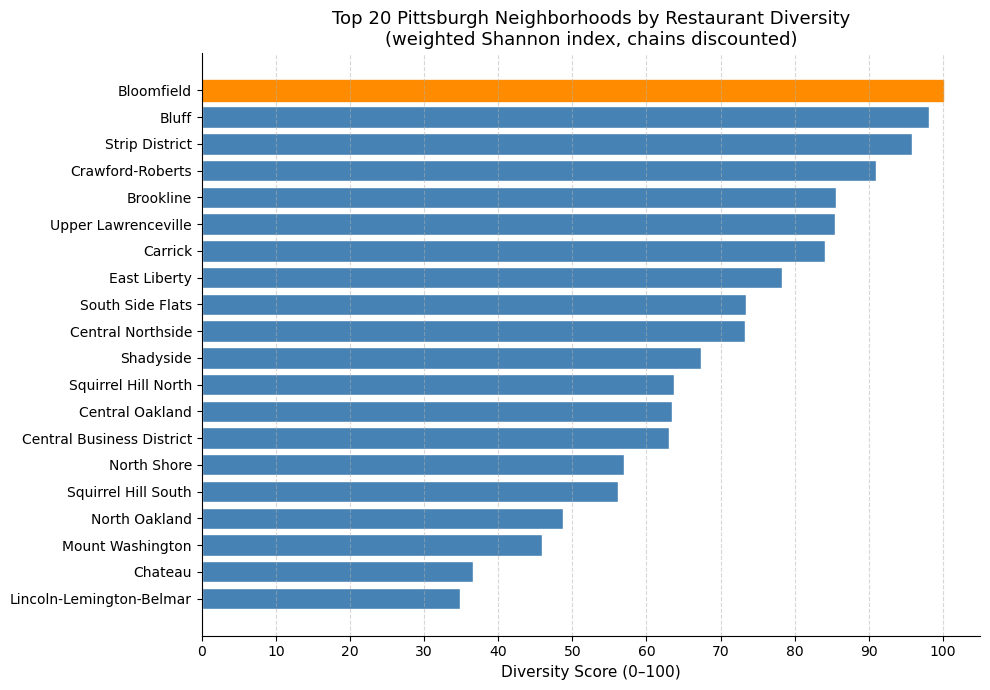


Best neighborhood by restaurant diversity: Bloomfield
Shannon diversity score: 1.314
Normalized score: 100.0 / 100
Total restaurants: 103


In [ ]:
top20 = diversity.head(20)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top20['hood'],
    top20['diversity_score'],
    color='steelblue',
    edgecolor='white'
)

#Highlight the top neighborhood
bars[0].set_color('darkorange')

ax.invert_yaxis()
ax.set_xlabel('Diversity Score (0–100)', fontsize=11)
ax.set_title('Top 20 Pittsburgh Neighborhoods by Restaurant Diversity\n(weighted Shannon index)', fontsize=13)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('diversity_scores.png', dpi=150, bbox_inches='tight')
plt.show()

best = diversity.iloc[0]
print(f"\nBest neighborhood by restaurant diversity: {best['hood']}")
print(f"Shannon diversity score: {best['shannon']:.3f}")
print(f"Normalized score: {best['diversity_score']:.1f} / 100")
print(f"Total restaurants: {int(best['total_restaurants'])}")

## Breakdown: What Types of Food Facilities Are in the Top Neighborhood?

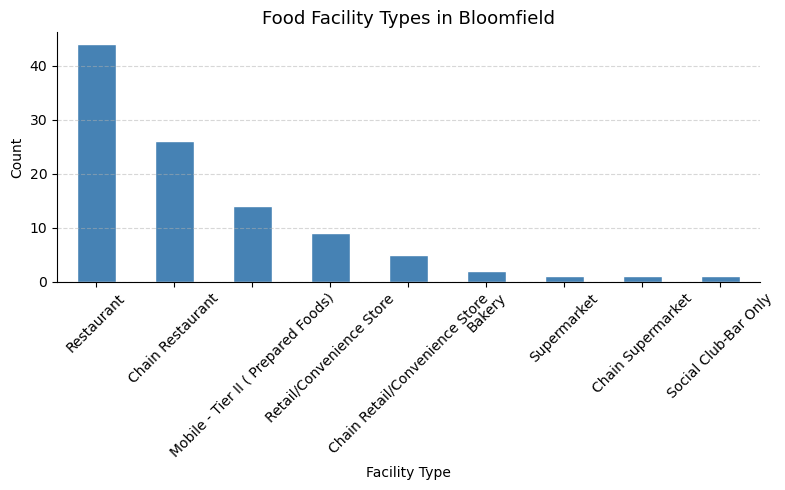

In [13]:
top_hood = diversity.iloc[0]['hood']

top_hood_types = (
    facilities_with_hood[facilities_with_hood['hood'] == top_hood]
    ['description']
    .value_counts()
)

fig, ax = plt.subplots(figsize=(8, 5))
top_hood_types.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Food Facility Types in {top_hood}', fontsize=13)
ax.set_xlabel('Facility Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('top_neighborhood_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Using the Allegheny County geocoded food facilities dataset, we ranked Pittsburgh neighborhoods using a weighted Shannon Diversity Index. We filtered to publicly accessible foodie-relevant establishments, collapsed the with/without liquor distinction, and weighted the types of facilities. The Shannon index rewards both variety of types and evenness of distribution, so a neighborhood with a balanced mix of different kinds of places scores higher than one dominated by a single type. Scores were normalized to 0–100 for easy combination with the group's other sub-metrics.

In [16]:
diversity_list = diversity[['hood', 'diversity_score']].values.tolist()
print(diversity_list)

[['Bloomfield', 100.0], ['Bluff', 98.14152999555814], ['Strip District', 95.79783959730128], ['Crawford-Roberts', 91.02185710925616], ['Brookline', 85.60781405367803], ['Upper Lawrenceville', 85.47394100411798], ['Carrick', 84.09056610864467], ['East Liberty', 78.29665126734312], ['South Side Flats', 73.47367982883716], ['Central Northside', 73.26381694732754], ['Shadyside', 67.38728020073827], ['Squirrel Hill North', 63.66707898624203], ['Central Oakland', 63.429235690735695], ['Central Business District', 63.00160574137684], ['North Shore', 56.94278703830618], ['Squirrel Hill South', 56.15329228126282], ['North Oakland', 48.7021828485102], ['Mount Washington', 45.94794691375797], ['Chateau', 36.54490567668703], ['Lincoln-Lemington-Belmar', 34.880744189308004], ['Lower Lawrenceville', 34.738604444348695], ['Central Lawrenceville', 27.851967121293924], ['South Shore', 19.085588642471805], ['East Allegheny', 0.0]]
